# Create Categories

**Objectives** 

Create categories from product descriptions and assign each product a category.

**Key Outputs** 

Modified 'products' table in SQLite database containing new column with category derived from product descriptions.

**Data** 

Data consists of single sentence descriptions queried from 'products' table in `data/sqliteDB/sales.db`. 


In [2]:
import sqlite3 as sql
import pandas as pd
import yaml

import numpy as np
import random
import torch

import re

# # Random seeds set for reproducible embeddings 
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

import seaborn as sns
import matplotlib as plt

from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize

from sklearn.cluster import KMeans 
from sklearn.metrics import silhouette_score

import warnings 
warnings.filterwarnings("ignore", category=RuntimeWarning) # Suppress harmless divide-by-zero warnings from scikit-learn distance computations

In [3]:
# --- Query Data --- #

Q_Products = "SELECT * FROM Raw_Products"

conn = sql.connect("../data/sqliteDB/sales.db")
Raw_Products = pd.read_sql_query(Q_Products,conn)
conn.close()

## Exploratory Data Analysis

First check for 
- Unique product codes
- Number of duplicate products 
- Invalid product codes
- Proportion of data with missing descriptions

Invalid unit codes are those that
1. Begin with the letter C (corresponds to cancelled invoices)
2. Do not begin with a 4-6 digit number


In [4]:
# Number of unique products
unique_prods = Raw_Products.drop_duplicates(subset='StockCode').copy()
print("Number of unique products: " + str(unique_prods.shape[0]))

# Check invalid unit codes
pattern = r"^(?!C)\d{4,6}.+$"
id_filter = ~unique_prods['StockCode'].str.match(pattern,na=False)
invalid_id = unique_prods[id_filter]
print("Number of invalid products: " + str(invalid_id.shape[0]))

# Number of descriptions with non unique StockCodes. 
print("Number of duplicate StockCodes: " + str(Raw_Products.shape[0]-unique_prods.shape[0]))

# Check for missing descriptions 
na_filter = Raw_Products['Description'].isna()
na_prop = na_filter.mean()
print("Proportion of NA descriptions: " + str(na_prop))


Number of unique products: 4070
Number of invalid products: 33
Number of duplicate StockCodes: 1682
Proportion of NA descriptions: 0.16689847009735745


Data contains invalid product codes, missing descriptions and duplicate descriptions for unique product codes. 

Next we look at basic measures for descriptions including 
- character count,
- token count and
- token density.

Outliers or low counts of these measures may indicate invalid descriptions. 

array([[<Axes: title={'center': 'char_count'}>,
        <Axes: title={'center': 'token_count'}>],
       [<Axes: title={'center': 'token_density'}>, <Axes: >]],
      dtype=object)

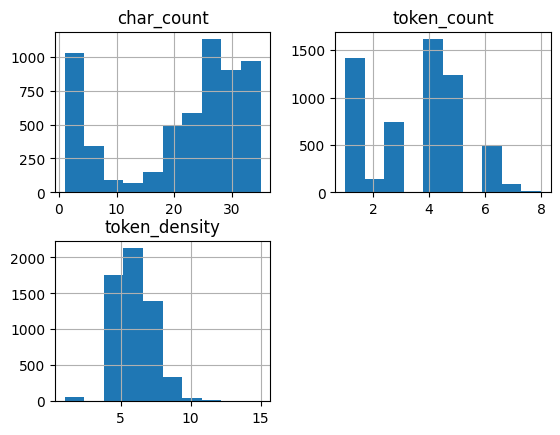

In [ ]:
# Obtain unique product description pair
unique_prods = Raw_Products.drop_duplicates(subset=['StockCode','Description']).copy()


# Token and character count
unique_prods['char_count'] = (
    unique_prods['Description']
    .astype(str)
    .str.len()
)

unique_prods['token_count'] = (
     unique_prods['Description']
     .astype(str)
     .str.split()
     .str.len()
)

unique_prods['token_density'] = (
    unique_prods['char_count']/unique_prods['token_count']
    )

# Distribution of counts
unique_prods[['char_count','token_count','token_density']].hist()

A substantial proportion of descriptions have either low characracters or tokens. In the cleaning phase, descriptions with
- caracter counts <= 10,
- token count <=2 and
- token density <= 3  

are marked for potential removal. 


## Data Cleaning

### Create Invalid Descriptions List

Potential invalid descriptions are flagged based on the description's character count, token count and token density measures. 

These descriptions are printed to `/logs/invalid_descp.txt`. 

In [ ]:
# ---  Outlier stock codes --- #
# Preprocessing
unique_prods['Description'] = unique_prods['Description'].astype(str).str.strip()
unique_prods['Description'] = unique_prods['Description'].str.replace('  ',' ')


# Gather descriptions with outlier statistics
char_out = unique_prods[unique_prods['char_count']<=10].dropna()
token_out = unique_prods[unique_prods['token_count']<=2].dropna()
density_out = unique_prods[unique_prods['token_density']<=3].dropna()


# Create invalid description list 
invalid_descriptions = []

invalid_descriptions.extend(list(char_out['Description']))
invalid_descriptions.extend(list(token_out['Description']))
invalid_descriptions.extend(list(density_out['Description']))

invalid_descriptions = list(set(invalid_descriptions))

# Save invalid descriptions 
DESCP_LOG_DIR = "../logs/invalid_descp.txt"
with open(DESCP_LOG_DIR,'w') as f:
    for entry in invalid_descriptions:
        f.write(entry + "\n")
    

Flagged potential invalid descriptions contain a mix of short real product descriptions and syetematic logs. Valid descriptions are removed from the invalid descriptions list. 

In [20]:
# --- Process False Flags --- #
# Obtain false flags from input file
FALSE_FLAGS_DIR = "../input/1_fasle_flags.yaml"

with open(FALSE_FLAGS_DIR,'r') as f:
    false_flags = yaml.safe_load(f)['false_flags']

# Remove false flags
invalid_descriptions = [dscrp for dscrp in invalid_descriptions if dscrp not in false_flags]
invalid_descriptions

['Display',
 'amazon sales',
 'michel oops',
 'FOUND',
 '????missing',
 'found',
 'Amazon Adjustment',
 'damages',
 'missing',
 'lost??',
 'Missing',
 'MIA',
 'Thrown away-rusty',
 'smashed',
 '???',
 'damages/dotcom?',
 'dotcom adjust',
 'water damaged',
 'damages/display',
 "can't find",
 'returned',
 'Crushed',
 'Breakages',
 'Given away',
 'ebay',
 're-adjustment',
 'mixed up',
 'wrongly marked',
 'wrong barcode',
 'dotcomstock',
 '?',
 'Dotcom sales',
 'wet?',
 'mouldy',
 'samples',
 'wrongly coded-23343',
 'damaged stock',
 '?missing',
 'sold as 1',
 'Damages',
 'taig adjust',
 'dotcom',
 '???missing',
 '20713',
 'crushed ctn',
 'website fixed',
 '??',
 'check',
 'wrong code',
 'barcode problem',
 '????damages????',
 'Thrown away.',
 'CHECK',
 'wet',
 'Amazon',
 'broken',
 'wrong code?',
 'wet boxes',
 'samples/damages',
 'stock check',
 'adjust',
 'amazon adjust',
 'SAMPLES',
 'Unsaleable, destroyed.',
 'test',
 'Adjustment',
 'wet rusty',
 'thrown away',
 'throw away',
 'Damage

### Remove Invalid Products

A dataframe containing all unique products with valid descriptions is now created. The Raw products is copied, then the following is applied:
1. Remove entries with invalid StockCode
2. Drop NAs for StockCodes with duplicate descriptions (if any)
3. Remove rows with descriptions matching entries in invalid_descriptions list. 
4. Fill remaining NA descriptions with value "NO DESCRIPTION". 

In [ ]:
# Copy dataframe
unique_prods = Raw_Products.copy()

# Remove entries with invalid StockCode
mask = ~unique_prods['StockCode'].isin(invalid_id['StockCode'])
unique_prods = unique_prods[mask]

# Remove Invalid descriptions within duplicate StockCodes
mask = ~(unique_prods.duplicated(subset='StockCode') & unique_prods['Description'].isna())
unique_prods = unique_prods[mask]

# Remove rows with invalid descriptions
mask = ~unique_prods['Description'].isin(invalid_descriptions)
unique_prods = unique_prods[mask]

# Fill missing descriptions with 'NO DESCRIPTION'
unique_prods['Description'] = unique_prods['Description'].fillna(value='NO DESCRIPTION')

## Category Generation

**Methodology**

Category generation is done is two steps.
1. Apply the embedding model  'all-MiniLM-L6-v2' to the product descriptions to produce a vector representation for each product. 
2. Apply Kmeans clustering of the product's vector in the word embedding space. This includes tuning the number of clusters by determining an appropriate cutoff for the silhouette score. 

The resulting clusteres are saved to `./logs/categories.txt`. 

In [23]:
# --- Apply Word Embedding --- #

# Embed Descriptions and normalise embedding
descriptions = unique_prods['Description'].str.lower()

model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(descriptions.tolist(), show_progress_bar=True)
embeddings_norm = normalize(embeddings)

Batches: 100%|██████████| 139/139 [00:05<00:00, 26.44it/s]


In [24]:
# Check zero rows
valid_rows = np.linalg.norm(embeddings_norm, axis=1) > 0
embeddings_norm[~valid_rows]


array([], shape=(0, 384), dtype=float32)

No row zeros in data. Kmeans clustering can be applied with zero division issues. 

We proceed with determining the appropriate number of clusters by tracking the Silhouette Coefficient. This score is commonly used for word embedding clustering, thus used here instead of the usual distortion score.  

<Axes: xlabel='K', ylabel='Silhouette Coefficient'>

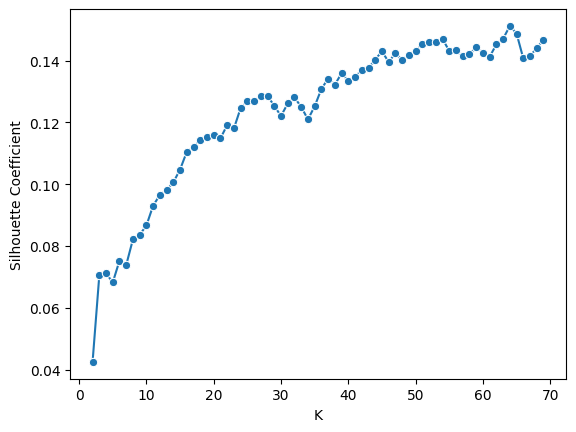

In [26]:
# --- Tune number of clusters using silhouette score --- #
scores = []

for k in range(2, 70):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(embeddings_norm)
    score = silhouette_score(embeddings_norm, labels, metric="cosine")
    scores.append((k, score))

df_sil = pd.DataFrame(scores, columns=["K", "Silhouette Coefficient"])

sns.lineplot(data=df_sil, x="K", y="Silhouette Coefficient", marker="o")


We choose 39 as the optimal number of clusters since it yields an acceptable silhouette score (approx. 0.138) and additional clusters do not yield significant improvement in score. 

After generating clusters with Kmeans, the cluster number and 25 descriptions words are printed to a text file in `/logs/categories.txt`. These should be checked to ensure that the categories are correct and groupings are appropriate. 

In [27]:
# --- Cluster --- #

k = 39  # determined above
kmeans = KMeans(n_clusters=k, random_state=42).fit(embeddings)

unique_prods['category_id'] = kmeans.labels_

# Print Categories to text file
CAT_LOG_DIR = "../logs/categories.txt"

with open(CAT_LOG_DIR, "w") as f:
    for i in range(k):
        f.write(f"\nCategory {i}\n")
        items = (
            unique_prods.loc[unique_prods['category_id'] == i, 'Description']
            .head(25)
            .tolist()
        )
        for item in items:
            f.write(f"  - {item}\n")

Certain clusters contain systematic descriptions and should be removed. Furthermore, several clusters contain similar descriptions and therefore can be merged. More importantly, we also need to assign a name to each of these clusters. 

The three tasks above are carried out in the `/input/1_categorgory_name.yaml` file. 

In [53]:
# --- Attached Categories to Data --- #
CATEGORY_DIR = "../input/1_category_name.yaml"

with open(CATEGORY_DIR, 'r') as f:
    categories = yaml.safe_load(f)

category_labels = categories['category_labels']
invalid_categories = categories['invalid_categories']

# Inspect category to be removed
unique_prods[unique_prods['category_id'].isin(invalid_categories)]

,StockCode,Description,category_id
3501,85172,wrongly sold as sets,33
3502,85175,Amazon sold sets,33
3503,85175,dotcom sold sets,33
3504,85175,wrongly sold sets,33
3505,85175,? sold as sets?,33
...,...,...,...
5457,22687,had been put aside,33
5458,22689,had been put aside,33
5528,22804,Wrongly mrked had 85123a in box,33
5529,85123A,wrongly marked carton 22804,33


We confirm that the cluster_id we specified in our yaml file contains invalid descriptions and should be removed. 

The naming and merging of clusters are carried out. The following code is used to map the new category and the new product table with product categories is saved into the SQLite database.

In [ ]:
#--- Save Categories in Product Table in SQL Database --- # 
# Remove invalid categories
mask = unique_prods['category_id'].isin(invalid_categories)
final_unique_prods = unique_prods[~mask].copy()

# Map new_category_id to labels 
final_unique_prods['CategoryLabel'] = final_unique_prods['category_id'].map(category_labels)
category_label = final_unique_prods[['StockCode','CategoryLabel']]

# Add categories into SQL database
DB_DIR = "../data/sqliteDB/sales.db"

conn = sql.connect(DB_DIR)

Products = Raw_Products.drop_duplicates(subset='StockCode')

Products = pd.merge(
    left = Products,
    right= category_label,
    how= 'left',
    on='StockCode'
    )

Products.to_sql('Products',conn,if_exists='replace',index=False)

conn.close()